In [8]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification
import random

In [2]:
X,y = make_classification(n_features=5, n_redundant=0, n_informative=5,n_clusters_per_class=1)

In [3]:
df = pd.DataFrame(X,columns=['col1','col2','col3','col4','col5'])
df['target'] = y
print(df.shape)
df.head()

(100, 6)


,col1,col2,col3,col4,col5,target
0,1.403163,0.514901,0.499812,0.623406,-1.186257,0
1,1.558888,0.057698,2.622790,-1.801898,-1.831465,0
2,1.172934,-0.256507,1.671083,-0.981193,2.396069,1
3,1.889241,0.119743,0.684087,2.293560,-2.007460,0
4,2.616106,-0.929020,0.587689,-2.441453,0.056878,1


In [9]:
# function for row sampling

def sample_rows(df,percent):
  return df.sample(int(percent*df.shape[0]),replace=True)

In [10]:
# function for feature sampling
def sample_features(df,percent):
  cols = random.sample(df.columns.tolist()[:-1],int(percent*(df.shape[1]-1)))
  new_df = df[cols]
  new_df['target'] = df['target']
  return new_df

In [11]:
# function for combined sampling

def combined_sampling(df,row_percent,col_percent):
  new_df = sample_rows(df,row_percent)
  return sample_features(new_df,col_percent)

In [12]:
df1 = combined_sampling(df,0.5,0.5)

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_6064\3275485051.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target'] = df['target']


In [13]:
df2 = combined_sampling(df,0.5,0.5)

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_6064\3275485051.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target'] = df['target']


In [14]:
df3 = combined_sampling(df,0.5,0.5)

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_6064\3275485051.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target'] = df['target']


In [15]:
print(df1.columns)
print(df2.columns)
print(df3.columns)

Index(['col4', 'col2', 'target'], dtype='object')
Index(['col4', 'col1', 'target'], dtype='object')
Index(['col4', 'col2', 'target'], dtype='object')


In [16]:
from sklearn.tree import DecisionTreeClassifier
clf1 = DecisionTreeClassifier()
clf2 = DecisionTreeClassifier()
clf3 = DecisionTreeClassifier()

In [17]:
clf1.fit(df1.iloc[:,0:2],df1.iloc[:,-1])
clf2.fit(df2.iloc[:,0:2],df2.iloc[:,-1])
clf3.fit(df3.iloc[:,0:2],df3.iloc[:,-1])

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [18]:
from sklearn.tree import plot_tree

[Text(0.47368421052631576, 0.9285714285714286, 'x[1] <= 0.017\ngini = 0.497\nsamples = 50\nvalue = [27, 23]'),
 Text(0.2631578947368421, 0.7857142857142857, 'x[1] <= -1.887\ngini = 0.435\nsamples = 25\nvalue = [8, 17]'),
 Text(0.3684210526315789, 0.8571428571428572, 'True  '),
 Text(0.21052631578947367, 0.6428571428571429, 'gini = 0.0\nsamples = 6\nvalue = [0, 6]'),
 Text(0.3157894736842105, 0.6428571428571429, 'x[0] <= -0.366\ngini = 0.488\nsamples = 19\nvalue = [8, 11]'),
 Text(0.2631578947368421, 0.5, 'x[0] <= -2.459\ngini = 0.43\nsamples = 16\nvalue = [5, 11]'),
 Text(0.15789473684210525, 0.35714285714285715, 'x[0] <= -2.914\ngini = 0.375\nsamples = 4\nvalue = [3, 1]'),
 Text(0.10526315789473684, 0.21428571428571427, 'x[0] <= -3.309\ngini = 0.5\nsamples = 2\nvalue = [1, 1]'),
 Text(0.05263157894736842, 0.07142857142857142, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.15789473684210525, 0.07142857142857142, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.21052631578947367

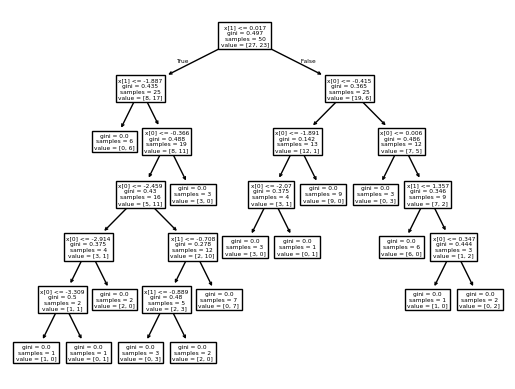

In [19]:
plot_tree(clf1)

[Text(0.671875, 0.95, 'x[1] <= 2.771\ngini = 0.497\nsamples = 50\nvalue = [23, 27]'),
 Text(0.546875, 0.85, 'x[1] <= -1.416\ngini = 0.495\nsamples = 40\nvalue = [22, 18]'),
 Text(0.609375, 0.8999999999999999, 'True  '),
 Text(0.484375, 0.75, 'gini = 0.0\nsamples = 3\nvalue = [0, 3]'),
 Text(0.609375, 0.75, 'x[1] <= 1.975\ngini = 0.482\nsamples = 37\nvalue = [22, 15]'),
 Text(0.40625, 0.65, 'x[1] <= 1.204\ngini = 0.498\nsamples = 30\nvalue = [16, 14]'),
 Text(0.25, 0.55, 'x[1] <= 0.532\ngini = 0.432\nsamples = 19\nvalue = [13, 6]'),
 Text(0.1875, 0.45, 'x[0] <= -2.308\ngini = 0.5\nsamples = 12\nvalue = [6, 6]'),
 Text(0.125, 0.35, 'gini = 0.0\nsamples = 4\nvalue = [4, 0]'),
 Text(0.25, 0.35, 'x[0] <= 0.03\ngini = 0.375\nsamples = 8\nvalue = [2, 6]'),
 Text(0.1875, 0.25, 'x[1] <= 0.052\ngini = 0.245\nsamples = 7\nvalue = [1, 6]'),
 Text(0.125, 0.15, 'x[1] <= -0.052\ngini = 0.444\nsamples = 3\nvalue = [1, 2]'),
 Text(0.0625, 0.05, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]'),
 Text(0.1875, 

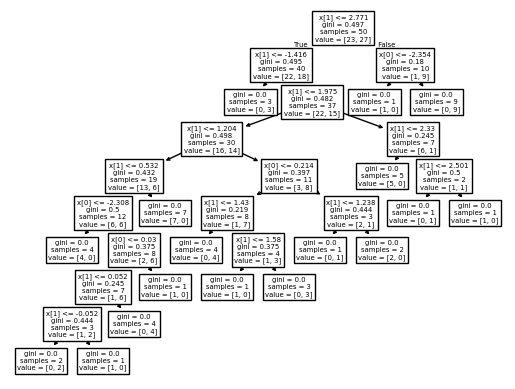

In [20]:
plot_tree(clf2)

[Text(0.3472222222222222, 0.9285714285714286, 'x[1] <= -0.799\ngini = 0.497\nsamples = 50\nvalue = [27, 23]'),
 Text(0.1111111111111111, 0.7857142857142857, 'x[0] <= -2.327\ngini = 0.291\nsamples = 17\nvalue = [3, 14]'),
 Text(0.22916666666666666, 0.8571428571428572, 'True  '),
 Text(0.05555555555555555, 0.6428571428571429, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.16666666666666666, 0.6428571428571429, 'x[1] <= -1.288\ngini = 0.219\nsamples = 16\nvalue = [2, 14]'),
 Text(0.1111111111111111, 0.5, 'gini = 0.0\nsamples = 11\nvalue = [0, 11]'),
 Text(0.2222222222222222, 0.5, 'x[1] <= -1.109\ngini = 0.48\nsamples = 5\nvalue = [2, 3]'),
 Text(0.16666666666666666, 0.35714285714285715, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.2777777777777778, 0.35714285714285715, 'gini = 0.0\nsamples = 3\nvalue = [0, 3]'),
 Text(0.5833333333333334, 0.7857142857142857, 'x[0] <= -2.229\ngini = 0.397\nsamples = 33\nvalue = [24, 9]'),
 Text(0.4652777777777778, 0.8571428571428572, '  False'),

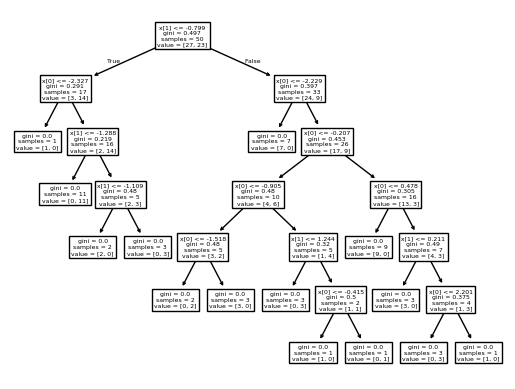

In [21]:
plot_tree(clf3)

In [22]:
clf1.predict(np.array([-1.042498,	-0.064323]).reshape(1,2))

C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [23]:
clf2.predict(np.array([-1.042498,	-0.064323]).reshape(1,2))

C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [24]:
clf3.predict(np.array([-1.042498,	-0.064323]).reshape(1,2))

C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [25]:
df.sample(14,replace=True)

,col1,col2,col3,col4,col5,target
44,-0.414040,2.378106,4.155866,1.088554,3.647177,1
24,1.216055,1.438985,3.457079,0.530935,2.954948,1
47,7.132221,-5.157639,-1.647390,-0.674185,2.768059,1
21,0.869459,0.757099,2.333657,-2.159682,-0.989532,0
53,3.734143,1.222116,2.423185,-1.498333,3.105876,1
66,2.420433,-1.390691,1.465870,-0.095013,1.894344,1
1,1.558888,0.057698,2.622790,-1.801898,-1.831465,0
58,1.718145,-2.933647,0.946651,1.649293,2.444597,1
23,2.839251,-1.757036,2.734752,0.795891,-2.056111,0
91,1.259875,0.113972,0.928323,-2.046229,0.272018,1


In [26]:
d1 = sample_rows(df,0.8)

In [27]:
d2 = sample_rows(df,0.8)

In [28]:
d3 = sample_rows(df,0.8)

In [29]:
print(d1.columns)
print(d2.columns)
print(d3.columns)

Index(['col1', 'col2', 'col3', 'col4', 'col5', 'target'], dtype='object')
Index(['col1', 'col2', 'col3', 'col4', 'col5', 'target'], dtype='object')
Index(['col1', 'col2', 'col3', 'col4', 'col5', 'target'], dtype='object')


In [40]:
from sklearn.tree import DecisionTreeClassifier
clf4 = DecisionTreeClassifier()
clf5 = DecisionTreeClassifier()
clf6 = DecisionTreeClassifier()

In [41]:
clf4.fit(d1.iloc[:,0:5],d1.iloc[:,-1])
clf5.fit(d2.iloc[:,0:5],d2.iloc[:,-1])
clf6.fit(d3.iloc[:,0:5],d3.iloc[:,-1])

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [42]:
from sklearn.tree import plot_tree

[Text(0.4444444444444444, 0.9, 'x[4] <= -0.408\ngini = 0.499\nsamples = 80\nvalue = [42, 38]'),
 Text(0.2222222222222222, 0.7, 'x[0] <= 0.338\ngini = 0.18\nsamples = 40\nvalue = [36, 4]'),
 Text(0.3333333333333333, 0.8, 'True  '),
 Text(0.1111111111111111, 0.5, 'gini = 0.0\nsamples = 3\nvalue = [0, 3]'),
 Text(0.3333333333333333, 0.5, 'x[1] <= -3.904\ngini = 0.053\nsamples = 37\nvalue = [36, 1]'),
 Text(0.2222222222222222, 0.3, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.4444444444444444, 0.3, 'gini = 0.0\nsamples = 36\nvalue = [36, 0]'),
 Text(0.6666666666666666, 0.7, 'x[3] <= -2.523\ngini = 0.255\nsamples = 40\nvalue = [6, 34]'),
 Text(0.5555555555555556, 0.8, '  False'),
 Text(0.5555555555555556, 0.5, 'gini = 0.0\nsamples = 5\nvalue = [5, 0]'),
 Text(0.7777777777777778, 0.5, 'x[4] <= -0.253\ngini = 0.056\nsamples = 35\nvalue = [1, 34]'),
 Text(0.6666666666666666, 0.3, 'x[2] <= 0.828\ngini = 0.5\nsamples = 2\nvalue = [1, 1]'),
 Text(0.5555555555555556, 0.1, 'gini = 0.0\nsampl

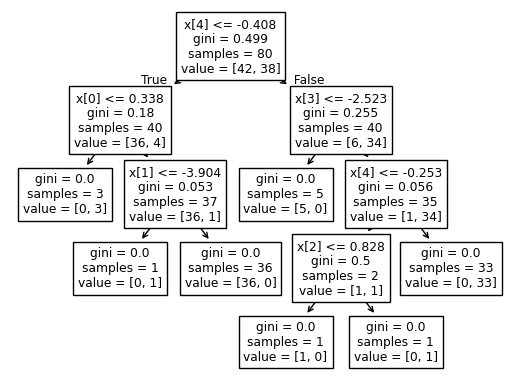

In [43]:
plot_tree(clf4)

[Text(0.5, 0.9, 'x[4] <= -0.108\ngini = 0.485\nsamples = 80\nvalue = [33, 47]'),
 Text(0.25, 0.7, 'x[4] <= -2.428\ngini = 0.198\nsamples = 36\nvalue = [32, 4]'),
 Text(0.375, 0.8, 'True  '),
 Text(0.125, 0.5, 'gini = 0.0\nsamples = 3\nvalue = [0, 3]'),
 Text(0.375, 0.5, 'x[4] <= -0.253\ngini = 0.059\nsamples = 33\nvalue = [32, 1]'),
 Text(0.25, 0.3, 'gini = 0.0\nsamples = 30\nvalue = [30, 0]'),
 Text(0.5, 0.3, 'x[0] <= 0.757\ngini = 0.444\nsamples = 3\nvalue = [2, 1]'),
 Text(0.375, 0.1, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.625, 0.1, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.75, 0.7, 'x[3] <= -3.523\ngini = 0.044\nsamples = 44\nvalue = [1, 43]'),
 Text(0.625, 0.8, '  False'),
 Text(0.625, 0.5, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.875, 0.5, 'gini = 0.0\nsamples = 43\nvalue = [0, 43]')]

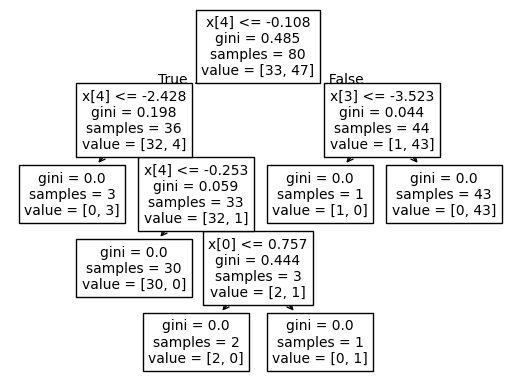

In [44]:
plot_tree(clf5)

[Text(0.375, 0.9285714285714286, 'x[4] <= 0.358\ngini = 0.5\nsamples = 80\nvalue = [40, 40]'),
 Text(0.25, 0.7857142857142857, 'x[0] <= -1.1\ngini = 0.32\nsamples = 50\nvalue = [40, 10]'),
 Text(0.3125, 0.8571428571428572, 'True  '),
 Text(0.125, 0.6428571428571429, 'gini = 0.0\nsamples = 4\nvalue = [0, 4]'),
 Text(0.375, 0.6428571428571429, 'x[4] <= -2.402\ngini = 0.227\nsamples = 46\nvalue = [40, 6]'),
 Text(0.25, 0.5, 'gini = 0.0\nsamples = 3\nvalue = [0, 3]'),
 Text(0.5, 0.5, 'x[1] <= -3.848\ngini = 0.13\nsamples = 43\nvalue = [40, 3]'),
 Text(0.375, 0.35714285714285715, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.625, 0.35714285714285715, 'x[4] <= -0.068\ngini = 0.091\nsamples = 42\nvalue = [40, 2]'),
 Text(0.5, 0.21428571428571427, 'gini = 0.0\nsamples = 37\nvalue = [37, 0]'),
 Text(0.75, 0.21428571428571427, 'x[1] <= 1.362\ngini = 0.48\nsamples = 5\nvalue = [3, 2]'),
 Text(0.625, 0.07142857142857142, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]'),
 Text(0.875, 0.071428571428

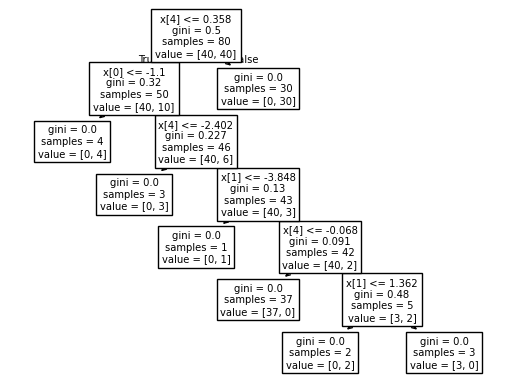

In [45]:
plot_tree(clf6)

In [36]:
d1

,col1,col2,col3,col4,col5,target
21,0.869459,0.757099,2.333657,-2.159682,-0.989532,0
53,3.734143,1.222116,2.423185,-1.498333,3.105876,1
49,2.039485,-0.120246,0.792041,-0.201485,-1.845095,0
19,0.246332,-0.522331,0.667309,-2.038042,1.845222,1
8,0.774242,1.414542,0.608562,-1.492094,-1.145560,0
...,...,...,...,...,...,...
78,3.019534,-1.867603,0.442776,-2.744094,-1.714863,0
56,-1.264584,3.612921,0.139673,-4.604730,1.197600,0
27,-0.611697,-0.023951,1.255671,-1.081302,2.334454,1
95,0.753993,0.601577,3.127967,0.597261,0.554764,1


In [48]:
clf4.predict(np.array([-0.611697	,-0.023951,1.255671,-1.081302,2.334454]).reshape(1,5))

C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [49]:
clf5.predict(np.array([-0.611697	,-0.023951,1.255671,-1.081302,2.334454]).reshape(1,5))

C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [50]:
clf6.predict(np.array([-0.611697	,-0.023951,1.255671,-1.081302,2.334454]).reshape(1,5))

C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])